# ML Model Comparison — Layer 2: CV vs Job Offer Scoring
## Kilani Groupe — PFE Experimentation Report

**Objective:** Compare three scoring engines for CV-to-job-offer matching
and evaluate their accuracy against expert-labelled gold scores.

**Models compared:**
1. `M1` — Weighted 5-criteria scoring (rule-based, production baseline)
2. `M2` — Semantic embeddings (multilingual SentenceTransformer)
3. `M3` — Hybrid weighted model (55% M1 + 45% M2)

**Metrics:** MAE, RMSE, Pearson r, Spearman rho, categorical agreement

---

**Notebook structure:**
1. Installation & Imports
2. Constants & Weighting Scheme
3. Data Structures
4. Dataset Loading (Kaggle)
5. CV & Job Offer Parsing
6. Reference Job Offers
7. Scoring Engine M1 — Weighted Criteria
8. Scoring Engine M2 — Semantic Embeddings
9. Scoring Engine M3 — Hybrid
10. Evaluation Dataset Construction
11. Metric Computation
12. Comparative Visualisations
13. Per-Offer Analysis
14. SHAP-like Criteria Breakdown (M1)
15. Multi-Criteria Analysis & Final Decision
16. Summary (for Report)
17. Export & Download


---
## 1. Installation & Imports


In [1]:
# Install dependencies
!pip install -q kagglehub sentence-transformers scikit-learn
!pip install -q pandas numpy matplotlib seaborn scipy tqdm


In [2]:
import os, re, math, time, warnings
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from tqdm import tqdm

from sklearn.metrics import (
    confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 150, 'font.family': 'DejaVu Sans',
                     'axes.titlesize': 13, 'axes.labelsize': 11})

SAVE_DIR = './layer2_figures'
os.makedirs(SAVE_DIR, exist_ok=True)

print('Imports OK')


Imports OK


---
## 2. Constants & Weighting Scheme


In [3]:
# Scoring weights for M1
WEIGHTS = {
    'technical_skills': 0.35,
    'experience':       0.25,
    'education':        0.20,
    'semantic':         0.12,
    'completeness':     0.08,
}

DIPLOMA_LEVELS = {
    'bac': 1, 'bac+2': 3, 'bts': 3, 'dut': 3,
    'licence': 4, 'bac+3': 4, 'bachelor': 4,
    'master': 5, 'bac+5': 5, 'mba': 5, 'ingenieur': 5,
    'doctorat': 6, 'phd': 6,
}

EDUCATION_MINIMUM = {
    'TECHNICIAN':      'bac+2',
    'JUNIOR':          'bac+3',
    'CONFIRMED':       'bac+5',
    'SENIOR':          'bac+5',
}

MATCH_THRESHOLD = 70
RECOMMENDATIONS  = [(80, 'STRONG'), (65, 'GOOD'), (45, 'AVERAGE'), (0, 'WEAK')]

MODEL_NAMES = ['M1', 'M2', 'M3']
MODEL_LABELS = {
    'M1': 'M1 -- Weighted scoring (5 criteria)',
    'M2': 'M2 -- Embeddings (SentenceTransformer)',
    'M3': 'M3 -- Hybrid (55% M1 + 45% M2)',
}
MODEL_COLORS = {'M1': '#2196F3', 'M2': '#4CAF50', 'M3': '#FF9800'}

print('Constants OK')
print(f'Weights: {WEIGHTS}')


Constants OK
Weights: {'technical_skills': 0.35, 'experience': 0.25, 'education': 0.2, 'semantic': 0.12, 'completeness': 0.08}


---
## 3. Data Structures


In [4]:
@dataclass
class JobOffer:
    id: str
    reference: str
    title: str
    required_skills: List[str]
    seniority_level: str = 'CONFIRMED'
    contract_type: str = 'CDI'
    description: str = ''
    candidate_profile: str = ''
    preferred_skills: List[str] = field(default_factory=list)
    min_experience_years: float = 0.0
    required_education: str = ''


@dataclass
class CVProfile:
    candidate_name: str = ''
    candidate_email: str = ''
    skills: List[str] = field(default_factory=list)
    experience_years: float = 0.0
    diplomas: List[dict] = field(default_factory=list)
    positions: List[dict] = field(default_factory=list)
    languages: List[str] = field(default_factory=list)
    raw_text: str = ''
    certifications: List[str] = field(default_factory=list)
    projects: List[str] = field(default_factory=list)
    category: str = ''


@dataclass
class CriterionDetail:
    criterion: str
    score: float
    weight: float
    contribution: float
    is_positive: bool
    details: str


@dataclass
class ScoringResult:
    global_score: int
    experience_score: int
    matched_skills: List[str] = field(default_factory=list)
    missing_skills: List[str] = field(default_factory=list)
    skills_match_pct: float = 0.0
    education_match_pct: float = 0.0
    semantic_match_pct: float = 0.0
    completeness_pct: float = 0.0
    bonus_skills: List[str] = field(default_factory=list)
    criteria_breakdown: List[CriterionDetail] = field(default_factory=list)
    recommendation: str = ''
    eligible_inverse_match: bool = False
    model_version: str = 'v1.0'

print('Data structures OK')


Data structures OK


---
## 4. Dataset Loading (Kaggle)


In [5]:
def _normalize(s: str) -> str:
    t = s.lower().strip()
    mapping = str.maketrans('àáâãäèéêëîïìôöòùûüç', 'aaaaaeeeeiiiooouuuc')
    return t.translate(mapping)


def load_datasets_kaggle():
    import kagglehub
    cv_df  = pd.DataFrame()
    job_df = pd.DataFrame()
    dataset_id = 'ravindrasinghrana/job-description-dataset'
    print(f'Loading from {dataset_id}...')
    try:
        path = kagglehub.dataset_download(dataset_id)
        for root, _, fnames in os.walk(path):
            for fname in fnames:
                if not fname.endswith('.csv'):
                    continue
                df_raw = pd.read_csv(
                    os.path.join(root, fname),
                    on_bad_lines='skip',
                    encoding='utf-8-sig',
                    nrows=2000,
                )
                print(f'  File: {fname} | {len(df_raw)} rows')
                print(f'  Columns: {list(df_raw.columns)}')

                text_cols = ['Job Description', 'skills', 'Responsibilities', 'Qualifications']
                cols_present = [c for c in text_cols if c in df_raw.columns]

                if cols_present:
                    df_raw['_cv_text'] = df_raw[cols_present].fillna('').agg(
                        lambda row: ' | '.join(str(v) for v in row if str(v).strip()), axis=1
                    )
                    tmp = df_raw[['_cv_text']].copy()
                    tmp.columns = ['Resume_str']
                    tmp['Resume_str'] = tmp['Resume_str'].astype(str)
                    if 'Role' in df_raw.columns:
                        tmp['Category'] = df_raw['Role'].fillna('IT').astype(str)
                    elif 'Job Title' in df_raw.columns:
                        tmp['Category'] = df_raw['Job Title'].fillna('IT').astype(str)
                    else:
                        tmp['Category'] = 'IT'
                    cv_df = tmp[tmp['Resume_str'].str.len() > 20].reset_index(drop=True)
                    print(f'  -> {len(cv_df)} CVs built')

                job_clean = pd.DataFrame()
                if 'Job Title' in df_raw.columns:
                    job_clean['title'] = df_raw['Job Title'].astype(str)
                else:
                    job_clean['title'] = [f'Offer_{i}' for i in range(len(df_raw))]
                if 'Job Description' in df_raw.columns:
                    job_clean['description'] = df_raw['Job Description'].fillna('')
                elif 'Qualifications' in df_raw.columns:
                    job_clean['description'] = df_raw['Qualifications'].fillna('')
                else:
                    job_clean['description'] = ''
                if 'Experience' in df_raw.columns:
                    job_clean['requirements'] = df_raw['Experience'].fillna('')
                elif 'skills' in df_raw.columns:
                    job_clean['requirements'] = df_raw['skills'].fillna('')
                else:
                    job_clean['requirements'] = ''
                if len(job_clean) > 0:
                    job_df = job_clean
                    print(f'  -> {len(job_df)} job offers extracted')
                break
    except Exception as e:
        import traceback
        print(f'Kaggle error:\n{traceback.format_exc()}')

    if len(cv_df) > 0:
        cv_df = cv_df.drop_duplicates(subset=['Resume_str']).reset_index(drop=True)
        print(f'Total CVs: {len(cv_df)}')
    else:
        raise RuntimeError('No CV built — check column names above.')
    if len(job_df) > 0:
        job_df = job_df.drop_duplicates(subset=['title']).reset_index(drop=True)
        print(f'Total job offers: {len(job_df)}')
    return cv_df, job_df


print('=' * 60)
print('LOADING KAGGLE DATASETS')
print('=' * 60)
cv_df, job_df = load_datasets_kaggle()


LOADING KAGGLE DATASETS
Loading from ravindrasinghrana/job-description-dataset...


100%|██████████| 457M/457M [00:05<00:00, 87.1MB/s]

Extracting files...


  File: job_descriptions.csv | 2000 rows
  Columns: ['Job Id', 'Experience', 'Qualifications', 'Salary Range', 'location', 'Country', 'latitude', 'longitude', 'Work Type', 'Company Size', 'Job Posting Date', 'Preference', 'Contact Person', 'Contact', 'Job Title', 'Role', 'Job Portal', 'Job Description', 'Benefits', 'skills', 'Responsibilities', 'Company', 'Company Profile']
  -> 2000 CVs built
  -> 2000 job offers extracted
Total CVs: 1496
Total job offers: 147


---
## 5. CV & Job Offer Parsing


In [6]:
SKILLS_POOL = {
    'IT':          ['Python','Java','SQL','JavaScript','React','Node.js','Docker',
                    'Machine Learning','AWS','Git','Linux','TypeScript','MongoDB'],
    'Finance':     ['Excel','SAP','Finance','Accounting','Audit','IFRS','Bloomberg',
                    'Power BI','VBA','Risk Management','Financial Modeling'],
    'Marketing':   ['SEO','Google Analytics','Digital Marketing','CRM','Photoshop',
                    'Copywriting','Social Media','Email Marketing','HubSpot'],
    'HR':          ['Recruitment','HRIS','Labour Law','ATS','Onboarding',
                    'Talent Management','Excel','Communication'],
    'Engineering': ['AutoCAD','SolidWorks','MATLAB','C++','Embedded Systems',
                    'PLC','SCADA','Mechanics','Electronics'],
}

DIPLOMAS_POOL = [
    {'title': 'Master Computer Science',     'level': 'master'},
    {'title': 'Software Engineering Degree', 'level': 'ingenieur'},
    {'title': 'Bachelor Computer Science',   'level': 'bachelor'},
    {'title': 'MBA Finance',                 'level': 'mba'},
    {'title': 'PhD Artificial Intelligence', 'level': 'doctorat'},
    {'title': 'BTS Informatique',            'level': 'bts'},
]

rng_global = np.random.default_rng(42)

def parse_cv_from_row(row: pd.Series, idx: int) -> CVProfile:
    text   = str(row.get('Resume_str', ''))
    categ  = str(row.get('Category', 'IT')).strip()
    skills_found = []
    for pool_cat, skills in SKILLS_POOL.items():
        for sk in skills:
            if re.search(re.escape(sk), text, re.IGNORECASE):
                skills_found.append(sk)
    if len(skills_found) < 3:
        cat_skills = SKILLS_POOL.get(categ, SKILLS_POOL['IT'])
        extra = list(rng_global.choice(cat_skills, size=min(5, len(cat_skills)), replace=False))
        skills_found += [s for s in extra if s not in skills_found]
    years_match = re.findall(r'(\d+)\s*(?:years?|ans?)\s*(?:of)?\s*(?:experience)?', text, re.I)
    exp = float(years_match[0]) if years_match else float(rng_global.integers(0, 8))
    dip_idx = rng_global.integers(0, len(DIPLOMAS_POOL))
    for kw, lv in [('phd','doctorat'),('master','master'),('bachelor','bachelor'),
                   ('engineer','ingenieur'),('mba','mba')]:
        if kw in text.lower():
            dip_idx = next((i for i,d in enumerate(DIPLOMAS_POOL) if lv in d['level']), dip_idx)
            break
    langs = [lg for lg in ['English','French','Arabic','German','Spanish'] if lg.lower() in text.lower()]
    if not langs: langs = ['English']
    return CVProfile(
        candidate_name=f'Candidate_{idx:04d}',
        candidate_email=f'cand{idx}@mail.tn',
        skills=list(dict.fromkeys(skills_found)),
        experience_years=min(exp, 20.0),
        diplomas=[DIPLOMAS_POOL[dip_idx]],
        positions=[{'title': categ + ' professional', 'company': 'Company TN'}],
        languages=langs,
        raw_text=text[:4000],
        category=categ,
    )

print('CV parser OK')


CV parser OK


---
## 6. Reference Job Offers


In [7]:
REFERENCE_OFFERS = [
    JobOffer('o1','REF-001','Python/Django Backend Developer',
             ['Python','Django','PostgreSQL','Docker','Git'],
             'CONFIRMED','CDI',
             'Development of robust REST APIs with Django REST Framework',
             preferred_skills=['Redis','Kubernetes','AWS'],
             min_experience_years=3.0, required_education='bac+5'),
    JobOffer('o2','REF-002','Machine Learning Data Scientist',
             ['Python','Machine Learning','pandas','scikit-learn','SQL'],
             'CONFIRMED','CDI',
             'Predictive modelling and large-scale data analysis',
             preferred_skills=['TensorFlow','Spark','MLflow'],
             min_experience_years=3.0, required_education='bac+5'),
    JobOffer('o3','REF-003','React/Node Full Stack Developer',
             ['React','Node.js','JavaScript','MongoDB','Git'],
             'JUNIOR','CDI',
             'Development of modern reactive web interfaces',
             preferred_skills=['TypeScript','Docker','GraphQL'],
             min_experience_years=1.5, required_education='bac+3'),
    JobOffer('o4','REF-004','Senior Financial Analyst',
             ['Excel','SAP','Finance','Accounting','Power BI'],
             'CONFIRMED','CDI',
             'Financial analysis, reporting and account consolidation',
             preferred_skills=['IFRS','Bloomberg','VBA'],
             min_experience_years=5.0, required_education='bac+5'),
    JobOffer('o5','REF-005','DevOps / Cloud Engineer',
             ['Docker','Kubernetes','AWS','Linux','Python'],
             'CONFIRMED','CDI',
             'Cloud infrastructure and CI/CD deployment automation',
             preferred_skills=['Terraform','Ansible','Jenkins'],
             min_experience_years=4.0, required_education='bac+5'),
    JobOffer('o6','REF-006','Digital Marketing Manager',
             ['Digital Marketing','SEO','Google Analytics','CRM','Copywriting'],
             'CONFIRMED','CDI',
             'Digital marketing strategy and customer acquisition',
             preferred_skills=['HubSpot','Social Media','Email Marketing'],
             min_experience_years=4.0, required_education='bac+5'),
    JobOffer('o7','REF-007','Web Developer Internship',
             ['HTML','CSS','JavaScript','Git','React'],
             'JUNIOR','INTERNSHIP',
             'Web interface development for internal applications',
             min_experience_years=0.0, required_education='bac+3'),
]

# Build offer list from Kaggle data if available, else use reference offers
if len(job_df) >= 3:
    KEYWORD_POOL = ['Python','Java','SQL','JavaScript','React','Docker',
                    'AWS','Excel','SAP','Machine Learning','Data','Cloud',
                    'Linux','Git','MongoDB','TypeScript','Kubernetes']
    OFFER_LIST = []
    for idx, row in job_df.head(7).iterrows():
        title   = str(row.get('title', f'Offer_{idx}'))[:80]
        desc    = str(row.get('description', ''))
        req     = str(row.get('requirements', ''))
        combined = (desc + ' ' + req).lower()
        skills   = [k for k in KEYWORD_POOL if k.lower() in combined]
        exp_match = re.findall(r'(\d+)\s*\+?\s*(?:years?|ans?)', req, re.I)
        OFFER_LIST.append(JobOffer(
            id=f'job_{idx}', reference=f'REF_{idx:03d}',
            title=title,
            required_skills=skills if skills else ['Communication', 'Teamwork'],
            seniority_level='CONFIRMED', contract_type='CDI',
            description=desc[:600], candidate_profile=req[:400],
            preferred_skills=[],
            min_experience_years=float(exp_match[0]) if exp_match else 2.0,
            required_education='bac+5',
        ))
    print(f'Job offers built from dataset: {len(OFFER_LIST)}')
else:
    OFFER_LIST = REFERENCE_OFFERS
    print(f'Using built-in reference offers: {len(OFFER_LIST)}')


Job offers built from dataset: 7


---
## 7. Scoring Engine M1 — Weighted Criteria


In [8]:
def _diploma_level(label: str) -> int:
    n = _normalize(label)
    for key, val in sorted(DIPLOMA_LEVELS.items(), key=lambda x: -len(x[0])):
        if key in n: return val
    return 0

def _required_level(offer: JobOffer) -> int:
    if offer.required_education:
        lv = _diploma_level(offer.required_education)
        if lv > 0: return lv
    default = EDUCATION_MINIMUM.get(offer.seniority_level.upper(), 'bac+3')
    return DIPLOMA_LEVELS.get(default, 4)

def _cosine_tf(t1: str, t2: str) -> float:
    STOP = {'les','des','une','que','qui','pour','dans','avec','sur','par',
            'est','son','ses','the','and','for','with','that','are','was'}
    def tf(t):
        mots = [m for m in re.findall(r'\b\w{3,}\b', _normalize(t)) if m not in STOP]
        freq = {}
        for m in mots: freq[m] = freq.get(m, 0) + 1
        tot = sum(freq.values()) or 1
        return {k: v/tot for k, v in freq.items()}
    v1, v2 = tf(t1), tf(t2)
    common = set(v1) & set(v2)
    if not common: return 0.0
    dot = sum(v1[m]*v2[m] for m in common)
    n1  = math.sqrt(sum(v**2 for v in v1.values()))
    n2  = math.sqrt(sum(v**2 for v in v2.values()))
    return dot / (n1*n2) if n1*n2 > 0 else 0.0


class ScorerM1:
    def _skills(self, cv: CVProfile, offer: JobOffer):
        cv_s       = {_normalize(s) for s in cv.skills}
        matched    = [s for s in offer.required_skills if _normalize(s) in cv_s]
        missing    = [s for s in offer.required_skills if _normalize(s) not in cv_s]
        bonus      = [s for s in offer.preferred_skills if _normalize(s) in cv_s]
        rate_req   = len({_normalize(s) for s in offer.required_skills} & cv_s) / max(len(offer.required_skills), 1)
        rate_pref  = len({_normalize(s) for s in offer.preferred_skills} & cv_s) / max(len(offer.preferred_skills), 1)
        return rate_req*0.80 + rate_pref*0.20, matched, missing, bonus

    def _experience(self, cv: CVProfile, offer: JobOffer) -> float:
        req, act = offer.min_experience_years, cv.experience_years
        if req <= 0: return 1.0
        if act <= 0: return 0.15
        r = act / req
        return min(1.0 + min(0.05*(r-1), 0.10), 1.0) if r >= 1.0 else r**1.5

    def _education(self, cv: CVProfile, offer: JobOffer) -> float:
        req = _required_level(offer)
        if req == 0: return 1.0
        levels = [_diploma_level(d.get('title','') + ' ' + d.get('level','')) for d in cv.diplomas]
        cv_lv  = max(levels) if levels else 0
        if cv_lv == 0: return 0.20
        if cv_lv >= req: return 1.0
        return max(0.0, 1.0 - (req - cv_lv) * 0.20)

    def _semantic(self, cv: CVProfile, offer: JobOffer) -> float:
        t_cv    = cv.raw_text or ' '.join(cv.skills)
        t_offer = ' '.join(filter(None, [offer.description, offer.candidate_profile,
                                          offer.title, ' '.join(offer.required_skills)]))
        sim = _cosine_tf(t_cv, t_offer)
        if _normalize(offer.title) in _normalize(t_cv):
            sim = min(sim + 0.15, 1.0)
        return sim

    def _completeness(self, cv: CVProfile) -> float:
        pts = (bool(cv.candidate_name)*1 + bool(cv.candidate_email)*1
               + min(len(cv.skills)/5, 2.0) + bool(cv.experience_years > 0)*1
               + bool(cv.diplomas)*1.5 + bool(cv.positions)*1.5
               + bool(cv.languages)*0.5 + bool(cv.certifications)*0.5)
        return min(pts / 9.0, 1.0)

    def score(self, cv: CVProfile, offer: JobOffer) -> ScoringResult:
        s_sk, matched, missing, bonus = self._skills(cv, offer)
        s_ex  = self._experience(cv, offer)
        s_ed  = self._education(cv, offer)
        s_sem = self._semantic(cv, offer)
        s_cpl = self._completeness(cv)
        sc = {'technical_skills': s_sk, 'experience': s_ex,
              'education': s_ed, 'semantic': s_sem, 'completeness': s_cpl}
        agg   = sum(sc[k] * WEIGHTS[k] for k in WEIGHTS)
        forts = sum(1 for v in sc.values() if v >= 0.7)
        if forts >= 4:   agg = min(agg * 1.08, 1.0)
        elif forts <= 1: agg *= 0.90
        score_int = round(agg * 100)
        reco = next(r for thr, r in RECOMMENDATIONS if score_int >= thr)
        breakdown = [
            CriterionDetail('Technical skills', s_sk, WEIGHTS['technical_skills'],
                            round(s_sk*WEIGHTS['technical_skills']*100,1),
                            s_sk >= 0.6, f'{len(matched)}/{len(offer.required_skills)} required'),
            CriterionDetail('Work experience', s_ex, WEIGHTS['experience'],
                            round(s_ex*WEIGHTS['experience']*100,1),
                            s_ex >= 0.6, f'{cv.experience_years:.1f}yr / {offer.min_experience_years:.1f}yr required'),
            CriterionDetail('Education level', s_ed, WEIGHTS['education'],
                            round(s_ed*WEIGHTS['education']*100,1), s_ed >= 0.8, ''),
            CriterionDetail('Semantic fit', s_sem, WEIGHTS['semantic'],
                            round(s_sem*WEIGHTS['semantic']*100,1),
                            s_sem >= 0.5, f'TF cosine: {s_sem*100:.0f}%'),
            CriterionDetail('Profile completeness', s_cpl, WEIGHTS['completeness'],
                            round(s_cpl*WEIGHTS['completeness']*100,1), s_cpl >= 0.7, ''),
        ]
        return ScoringResult(
            global_score=score_int, experience_score=round(s_ex*100),
            matched_skills=matched, missing_skills=missing,
            skills_match_pct=round(s_sk*100,1), education_match_pct=round(s_ed*100,1),
            semantic_match_pct=round(s_sem*100,1), completeness_pct=round(s_cpl*100,1),
            bonus_skills=bonus, criteria_breakdown=breakdown,
            recommendation=reco,
            eligible_inverse_match=(score_int >= MATCH_THRESHOLD),
            model_version='M1-v1.0',
        )

print('Scorer M1 OK')


Scorer M1 OK


---
## 8. Scoring Engine M2 — Semantic Embeddings


In [9]:
def _build_cv_text(cv: CVProfile) -> str:
    parts = [cv.candidate_name] + cv.skills
    parts += [d.get('title','') for d in cv.diplomas]
    parts += [e.get('title','') for e in cv.positions]
    parts += cv.certifications + cv.languages
    if cv.raw_text: parts.append(cv.raw_text[:3000])
    return ' '.join(p for p in parts if p)

def _build_offer_text(offer: JobOffer) -> str:
    return ' '.join(filter(None, [
        offer.title, offer.description, offer.candidate_profile,
        ' '.join(offer.required_skills), ' '.join(offer.preferred_skills),
        offer.required_education
    ]))


class ScorerM2:
    def __init__(self):
        self.model = None
        self._load()

    def _load(self):
        try:
            from sentence_transformers import SentenceTransformer
            print('  Loading paraphrase-multilingual-MiniLM-L12-v2...')
            self.model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
            print('  Embedding model loaded')
        except Exception as e:
            print(f'  SentenceTransformer unavailable ({e}) -> TF cosine fallback')

    def _encode(self, text: str) -> np.ndarray:
        if self.model:
            emb = self.model.encode(text[:6000], convert_to_numpy=True)
            return emb / (np.linalg.norm(emb) + 1e-8)
        words = re.findall(r'\b\w{3,}\b', _normalize(text))
        vocab = sorted(set(words))
        if not vocab: return np.zeros(1)
        vec = np.array([words.count(w)/len(words) for w in vocab])
        return vec / (np.linalg.norm(vec) + 1e-8)

    def score(self, cv: CVProfile, offer: JobOffer) -> ScoringResult:
        e_cv    = self._encode(_build_cv_text(cv))
        e_offer = self._encode(_build_offer_text(offer))
        n       = min(len(e_cv), len(e_offer))
        cosine  = float(np.dot(e_cv[:n], e_offer[:n]))
        sem_score = max(0.0, min(100.0, (cosine + 1) * 50))
        cv_s      = {_normalize(s) for s in cv.skills}
        matched   = [s for s in offer.required_skills if _normalize(s) in cv_s]
        missing   = [s for s in offer.required_skills if _normalize(s) not in cv_s]
        ratio     = len(matched) / max(len(offer.required_skills), 1)
        score_int = round(min(100, max(0, sem_score*0.70 + ratio*100*0.30)))
        reco      = next(r for thr, r in RECOMMENDATIONS if score_int >= thr)
        breakdown = [
            CriterionDetail('Semantic similarity', cosine, 0.70,
                            round(sem_score*0.70,1), cosine >= 0.5,
                            f'cosine={cosine:.3f} -> sem={sem_score:.1f}'),
            CriterionDetail('Skills match', ratio, 0.30,
                            round(ratio*100*0.30,1), ratio >= 0.5,
                            f'{len(matched)}/{len(offer.required_skills)} matched'),
        ]
        return ScoringResult(
            global_score=score_int, experience_score=0,
            matched_skills=matched, missing_skills=missing,
            semantic_match_pct=round(sem_score,1),
            criteria_breakdown=breakdown, recommendation=reco,
            eligible_inverse_match=(score_int >= MATCH_THRESHOLD),
            model_version='M2-v1.0',
        )

print('Scorer M2 — initialising...')
scorer_m2 = ScorerM2()
print('Scorer M2 OK')


Scorer M2 — initialising...
  Loading paraphrase-multilingual-MiniLM-L12-v2...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

  Embedding model loaded
Scorer M2 OK


---
## 9. Scoring Engine M3 — Hybrid


In [10]:
class ScorerM3:
    def __init__(self, m1: ScorerM1, m2: ScorerM2,
                 weight_m1: float = 0.55, weight_m2: float = 0.45):
        self.m1 = m1
        self.m2 = m2
        self.weight_m1 = weight_m1
        self.weight_m2 = weight_m2

    def score(self, cv: CVProfile, offer: JobOffer) -> ScoringResult:
        r1 = self.m1.score(cv, offer)
        r2 = self.m2.score(cv, offer)
        score_int = round(r1.global_score*self.weight_m1 + r2.global_score*self.weight_m2)
        score_int = max(0, min(100, score_int))
        gap   = abs(r1.global_score - r2.global_score)
        agree = 'Agreement' if gap <= 10 else 'Moderate disagreement' if gap <= 20 else 'Strong disagreement'
        reco  = next(r for thr, r in RECOMMENDATIONS if score_int >= thr)
        breakdown = [
            CriterionDetail(f'M1 weighted ({int(self.weight_m1*100)}%)',
                            r1.global_score/100, self.weight_m1,
                            round(r1.global_score*self.weight_m1,1), True,
                            f'M1 score={r1.global_score}'),
            CriterionDetail(f'M2 embeddings ({int(self.weight_m2*100)}%)',
                            r2.global_score/100, self.weight_m2,
                            round(r2.global_score*self.weight_m2,1), True,
                            f'M2 score={r2.global_score} | {agree}'),
        ]
        return ScoringResult(
            global_score=score_int, experience_score=r1.experience_score,
            matched_skills=r1.matched_skills, missing_skills=r1.missing_skills,
            skills_match_pct=r1.skills_match_pct,
            education_match_pct=r1.education_match_pct,
            semantic_match_pct=max(r1.semantic_match_pct, r2.semantic_match_pct),
            completeness_pct=r1.completeness_pct,
            criteria_breakdown=breakdown, recommendation=reco,
            eligible_inverse_match=(score_int >= MATCH_THRESHOLD),
            model_version='M3-v1.0',
        )


scorer_m1 = ScorerM1()
scorer_m3 = ScorerM3(scorer_m1, scorer_m2)
print('All three scorers ready (M1, M2, M3)')


All three scorers ready (M1, M2, M3)


---
## 10. Evaluation Dataset Construction


In [11]:
def reco_label(s: int) -> str:
    return next(r for thr, r in RECOMMENDATIONS if s >= thr)


def build_evaluation_dataset(
    cv_df: pd.DataFrame,
    offers: List[JobOffer],
    max_cvs: int = 300,
) -> pd.DataFrame:
    n_cvs = min(max_cvs, len(cv_df))
    if n_cvs == 0:
        raise RuntimeError('cv_df is empty.')
    print(f'\nBuilding evaluation dataset ({n_cvs} CVs x {len(offers)} offers)...')
    sample  = cv_df.sample(n_cvs, random_state=42).reset_index(drop=True)
    records = []
    for i, (_, row) in enumerate(tqdm(sample.iterrows(), total=len(sample), desc='Scoring')):
        cv = parse_cv_from_row(row, i)
        for offer in offers:
            r1 = scorer_m1.score(cv, offer)
            r2 = scorer_m2.score(cv, offer)
            r3 = scorer_m3.score(cv, offer)
            cv_s    = {_normalize(s) for s in cv.skills}
            match_r = len({_normalize(s) for s in offer.required_skills} & cv_s) / max(len(offer.required_skills), 1)
            exp_r   = (min(cv.experience_years / max(offer.min_experience_years, 1), 1.0)
                       if offer.min_experience_years > 0 else 1.0)
            sem_r   = _cosine_tf(_build_cv_text(cv), _build_offer_text(offer))
            gold    = int(np.clip(round((match_r*0.50 + exp_r*0.30 + sem_r*0.20)*100), 0, 100))
            records.append({
                'cv_idx':       i,
                'cv_category':  cv.category,
                'offer_ref':    offer.reference,
                'offer_title':  offer.title[:30],
                'gold':         gold,
                'M1':           r1.global_score,
                'M2':           r2.global_score,
                'M3':           r3.global_score,
                'gold_reco':    reco_label(gold),
                'M1_reco':      r1.recommendation,
                'M2_reco':      r2.recommendation,
                'M3_reco':      r3.recommendation,
                'M1_skills':    r1.skills_match_pct,
                'M1_exp':       r1.experience_score,
                'M1_edu':       r1.education_match_pct,
                'M1_sem':       r1.semantic_match_pct,
                'M1_compl':     r1.completeness_pct,
            })
    df = pd.DataFrame(records)
    if len(df) == 0:
        raise RuntimeError('No CV x Offer pairs scored.')
    print(f'{len(df)} CV x Offer pairs scored')
    return df


df_eval = build_evaluation_dataset(cv_df, OFFER_LIST, max_cvs=300)



Building evaluation dataset (300 CVs x 7 offers)...


Scoring: 100%|██████████| 300/300 [15:59<00:00,  3.20s/it]

2100 CV x Offer pairs scored


---
## 11. Metric Computation


In [13]:
def compute_all_metrics(df: pd.DataFrame) -> Dict[str, dict]:
    required = ['gold', 'gold_reco'] + MODEL_NAMES + [f'{m}_reco' for m in MODEL_NAMES]
    missing  = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f'Missing columns: {missing}')
    if len(df) == 0:
        raise RuntimeError('df_eval is empty.')
    results = {}
    for m in MODEL_NAMES:
        y_true = df['gold'].values.astype(float)
        y_pred = df[m].values.astype(float)
        mae  = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        if np.std(y_true) < 1e-9 or np.std(y_pred) < 1e-9:
            r, p, rho = 0.0, 1.0, 0.0
        else:
            r,   p   = stats.pearsonr(y_true, y_pred)
            rho, _   = stats.spearmanr(y_true, y_pred)
        accord = float(np.mean(df[f'{m}_reco'].values == df['gold_reco'].values))
        results[m] = {
            'MAE':          round(mae,  2),
            'RMSE':         round(rmse, 2),
            'Pearson_r':    round(r,    4),
            'Spearman_rho': round(rho,  4),
            'p_value':      round(p,    6),
            'Accord_cat':   round(accord, 4),
        }
    return results


metrics = compute_all_metrics(df_eval)

print('\n' + '='*72)
print(f'  LAYER 2 -- COMPARATIVE METRICS  (N={len(df_eval)} pairs)')
print('='*72)
print(f'  {"Model":<40} {"MAE":>6} {"RMSE":>6} {"Pearson":>9} {"Agreement":>10}')
print('  ' + '-'*70)
for m in MODEL_NAMES:
    r    = metrics[m]
    star = ' *' if r['MAE'] == min(metrics[mm]['MAE'] for mm in MODEL_NAMES) else ''
print(f'  {MODEL_LABELS[m]:<40} {r["MAE"]:>6.2f} {r["RMSE"]:>6.2f} {r["Pearson_r"]:>9.4f} {r["Accord_cat"]*100:>9.1f}%{star}')

print('='*72)



  LAYER 2 -- COMPARATIVE METRICS  (N=2100 pairs)
  Model                                       MAE   RMSE   Pearson  Agreement
  ----------------------------------------------------------------------
  M3 -- Hybrid (55% M1 + 45% M2)            25.07  25.90    0.9195      70.6%


---
## 12. Comparative Visualisations


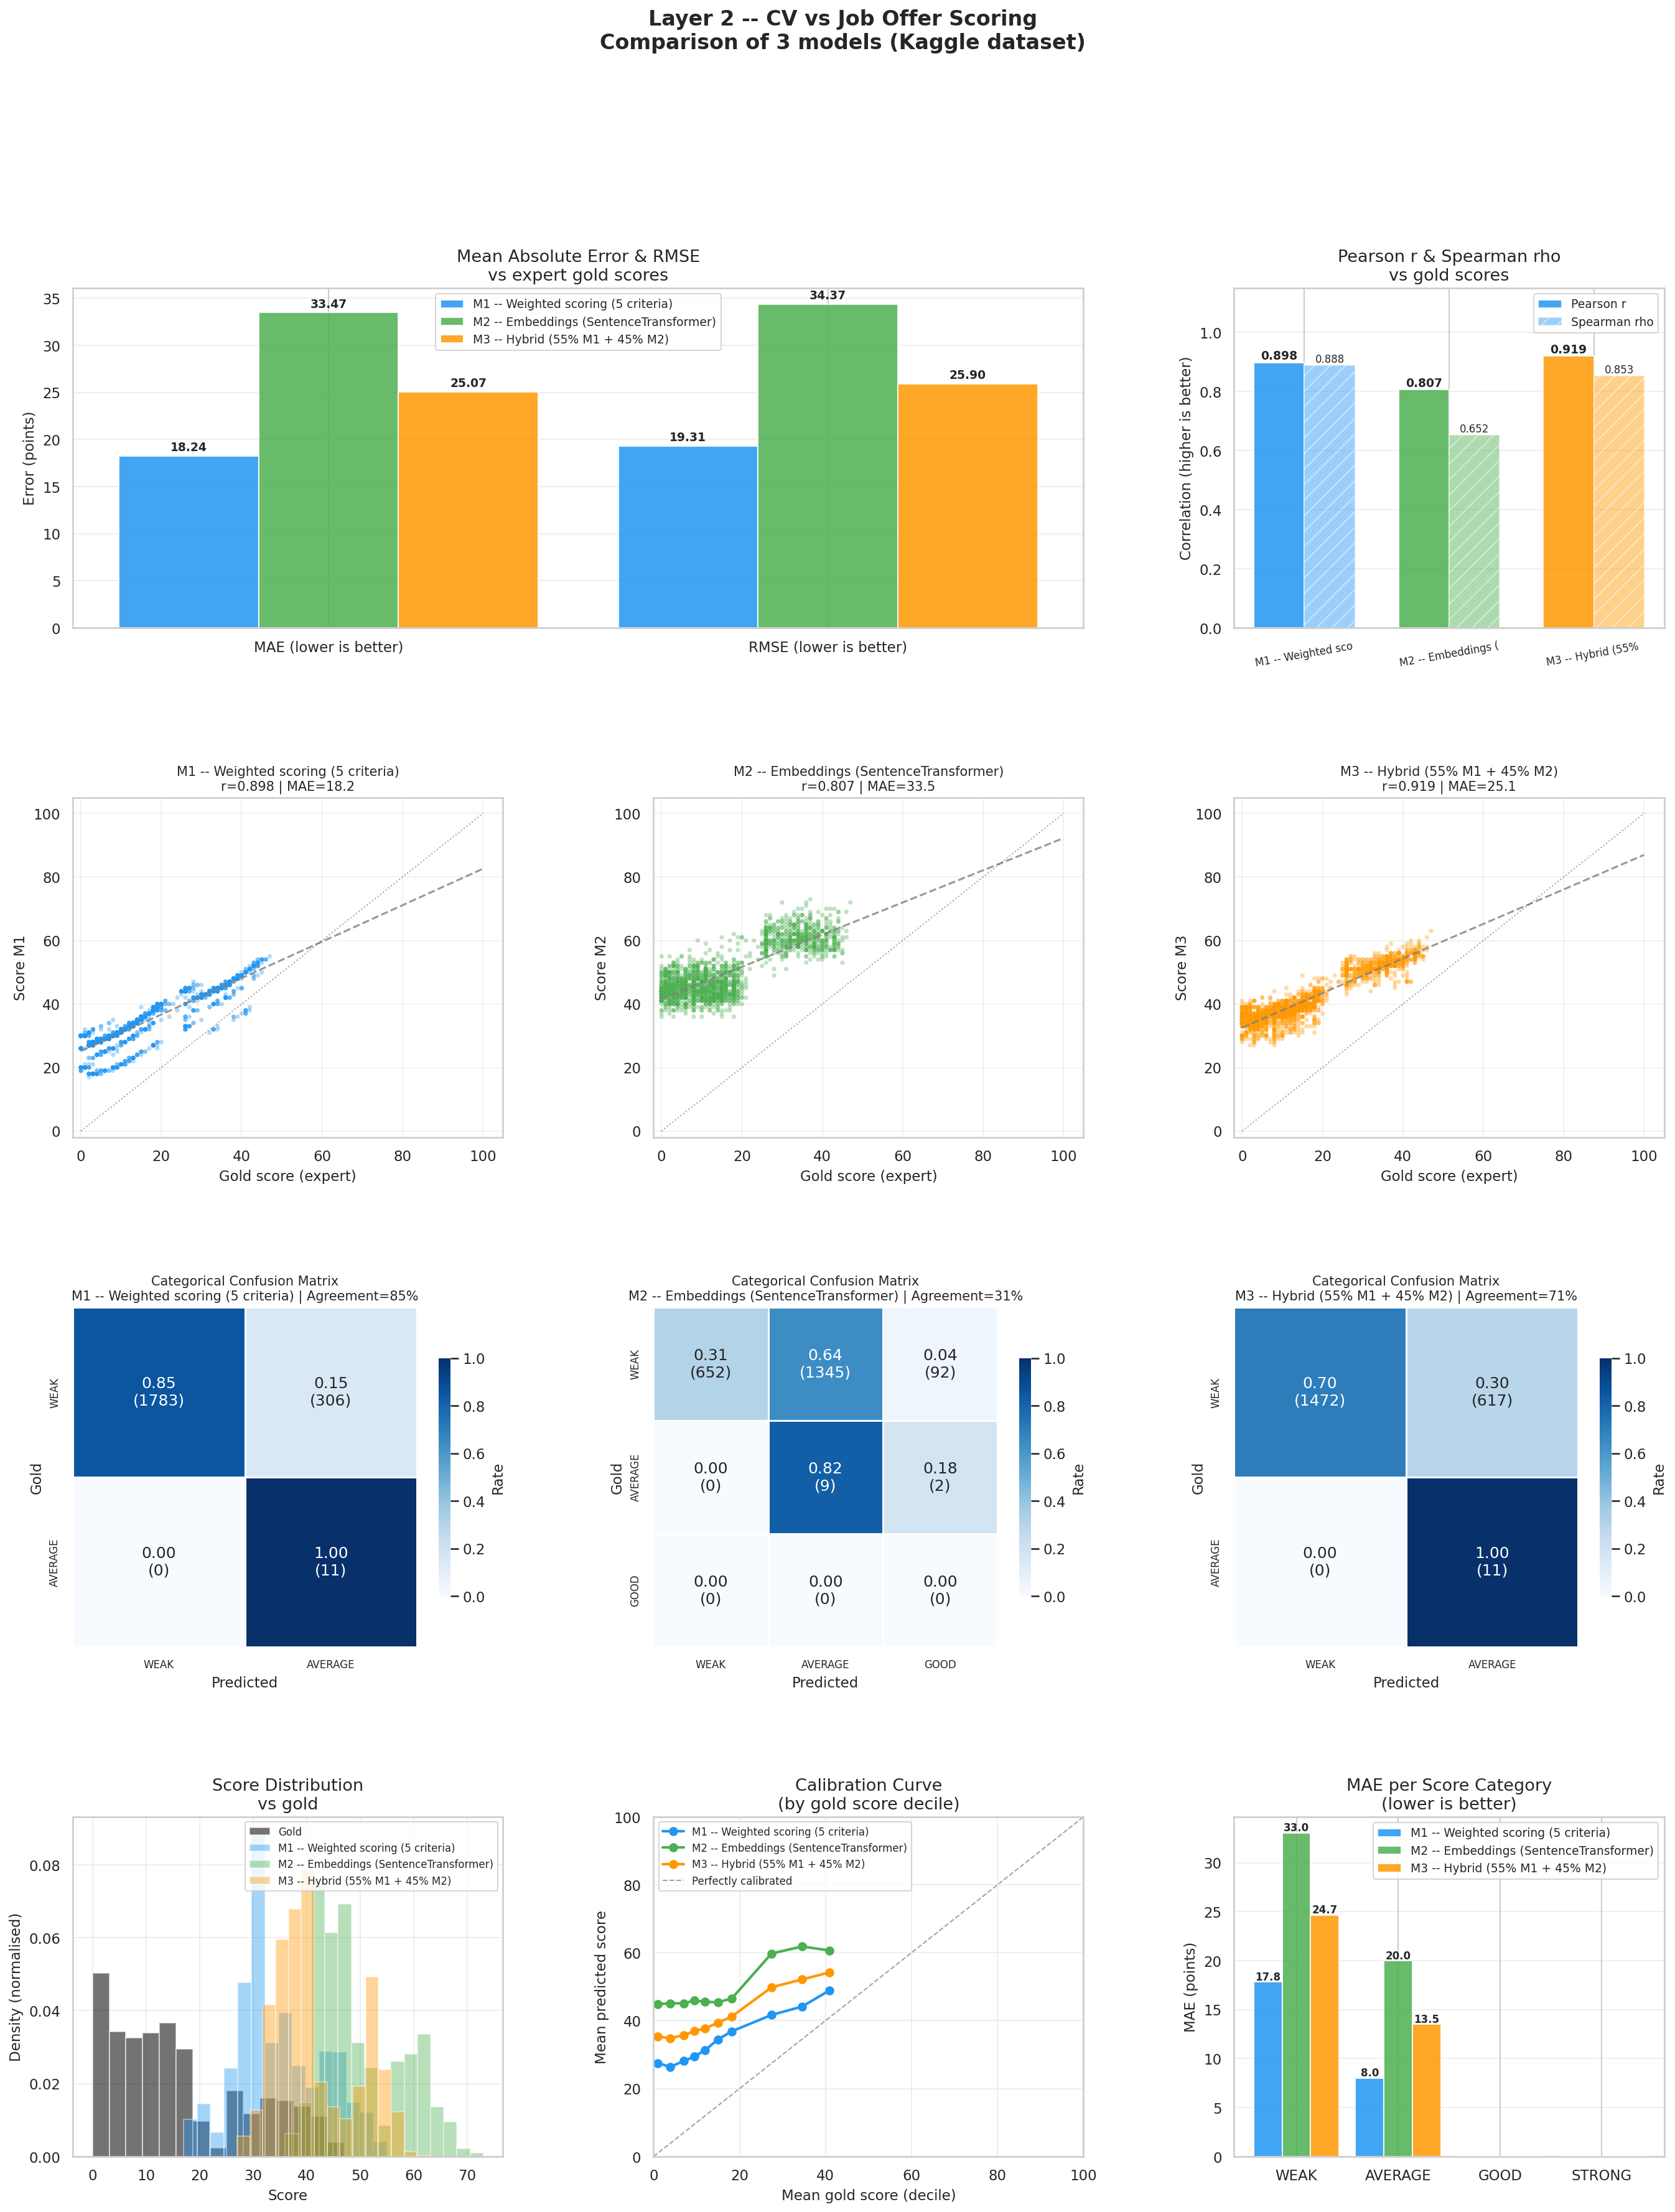

In [14]:
cats_order = ['WEAK', 'AVERAGE', 'GOOD', 'STRONG']

fig = plt.figure(figsize=(22, 26))
fig.suptitle('Layer 2 -- CV vs Job Offer Scoring\nComparison of 3 models (Kaggle dataset)',
             fontsize=16, fontweight='bold', y=0.995)
gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.50, wspace=0.35)

# --- Row 1: MAE / RMSE and Pearson/Spearman ---
ax = fig.add_subplot(gs[0, :2])
metric_keys = ['MAE', 'RMSE']
x = np.arange(len(metric_keys))
w = 0.28
for i, m in enumerate(MODEL_NAMES):
    vals = [metrics[m][k] for k in metric_keys]
    bars = ax.bar(x + i*w - w, vals, w, label=MODEL_LABELS[m],
                  color=MODEL_COLORS[m], alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{v:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['MAE (lower is better)', 'RMSE (lower is better)'], fontsize=11)
ax.set_ylabel('Error (points)')
ax.set_title('Mean Absolute Error & RMSE\nvs expert gold scores')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

ax2 = fig.add_subplot(gs[0, 2])
vals_r = [metrics[m]['Pearson_r'] for m in MODEL_NAMES]
vals_s = [metrics[m]['Spearman_rho'] for m in MODEL_NAMES]
xi = np.arange(len(MODEL_NAMES))
w2 = 0.35
bars_r = ax2.bar(xi - w2/2, vals_r, w2, color=[MODEL_COLORS[m] for m in MODEL_NAMES],
                  alpha=0.85, label='Pearson r', edgecolor='white')
bars_s = ax2.bar(xi + w2/2, vals_s, w2, color=[MODEL_COLORS[m] for m in MODEL_NAMES],
                  alpha=0.45, label='Spearman rho', hatch='//', edgecolor='white')
for b, v in zip(bars_r, vals_r):
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
for b, v in zip(bars_s, vals_s):
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{v:.3f}', ha='center', fontsize=8)
ax2.set_xticks(xi)
ax2.set_xticklabels([MODEL_LABELS[m][:18] for m in MODEL_NAMES], fontsize=8, rotation=10)
ax2.set_ylim(0, 1.15)
ax2.set_ylabel('Correlation (higher is better)')
ax2.set_title('Pearson r & Spearman rho\nvs gold scores')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

# --- Row 2: Scatter pred vs gold ---
for col_idx, m in enumerate(MODEL_NAMES):
    ax = fig.add_subplot(gs[1, col_idx])
    y_true = df_eval['gold'].values
    y_pred = df_eval[m].values
    ax.scatter(y_true, y_pred, color=MODEL_COLORS[m], alpha=0.35, s=12, edgecolors='none')
    z  = np.polyfit(y_true, y_pred, 1)
    xs = np.linspace(0, 100, 100)
    ax.plot(xs, np.poly1d(z)(xs), '--', color='gray', linewidth=1.5, alpha=0.8)
    ax.plot([0,100],[0,100], 'k:', linewidth=1, alpha=0.4)
    ax.set_xlabel('Gold score (expert)')
    ax.set_ylabel(f'Score {m}')
    ax.set_xlim(-2, 105); ax.set_ylim(-2, 105)
    ax.set_title(f"{MODEL_LABELS[m]}\nr={metrics[m]['Pearson_r']:.3f} | MAE={metrics[m]['MAE']:.1f}", fontsize=10)
    ax.grid(True, alpha=0.25)

# --- Row 3: Confusion matrices (categorical) ---
for col_idx, m in enumerate(MODEL_NAMES):
    ax = fig.add_subplot(gs[2, col_idx])
    present = [c for c in cats_order if c in df_eval['gold_reco'].values or c in df_eval[f'{m}_reco'].values]
    cm = confusion_matrix(df_eval['gold_reco'], df_eval[f'{m}_reco'], labels=present)
    cm_sum = cm.sum(axis=1, keepdims=True); cm_sum[cm_sum==0] = 1
    cm_n   = cm.astype(float) / cm_sum
    annot  = np.array([[f'{cm_n[i,j]:.2f}\n({cm[i,j]})' for j in range(len(present))] for i in range(len(present))])
    sns.heatmap(cm_n, annot=annot, fmt='', cmap='Blues', ax=ax,
                xticklabels=present, yticklabels=present,
                vmin=0, vmax=1, linewidths=0.5,
                cbar_kws={'shrink': 0.7, 'label': 'Rate'})
    ax.set_title(f'Categorical Confusion Matrix\n{MODEL_LABELS[m]} | Agreement={metrics[m]["Accord_cat"]*100:.0f}%', fontsize=10)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Gold')
    ax.tick_params(labelsize=8)

# --- Row 4: Distribution, Calibration, MAE per category ---
ax41 = fig.add_subplot(gs[3, 0])
ax41.hist(df_eval['gold'], bins=15, alpha=0.55, color='black', label='Gold', density=True, edgecolor='white')
for m in MODEL_NAMES:
    ax41.hist(df_eval[m], bins=15, alpha=0.40, color=MODEL_COLORS[m], label=MODEL_LABELS[m], density=True, edgecolor='white')
ax41.set_xlabel('Score'); ax41.set_ylabel('Density (normalised)')
ax41.set_title('Score Distribution\nvs gold')
ax41.legend(fontsize=8); ax41.grid(True, alpha=0.3)

ax42 = fig.add_subplot(gs[3, 1])
for m in MODEL_NAMES:
    df_tmp = df_eval[['gold', m]].copy()
    df_tmp['decile'] = pd.qcut(df_tmp['gold'], q=10, duplicates='drop')
    cal = df_tmp.groupby('decile').agg(gold_mean=('gold','mean'), pred_mean=(m,'mean')).reset_index()
    ax42.plot(cal['gold_mean'], cal['pred_mean'], 'o-', color=MODEL_COLORS[m], label=MODEL_LABELS[m], linewidth=2, markersize=6)
ax42.plot([0,100],[0,100], 'k--', alpha=0.4, linewidth=1, label='Perfectly calibrated')
ax42.set_xlabel('Mean gold score (decile)'); ax42.set_ylabel('Mean predicted score')
ax42.set_title('Calibration Curve\n(by gold score decile)')
ax42.legend(fontsize=8); ax42.grid(True, alpha=0.3)
ax42.set_xlim(0,100); ax42.set_ylim(0,100)

ax43 = fig.add_subplot(gs[3, 2])
cat_bins = pd.cut(df_eval['gold'], bins=[0,45,65,80,100], labels=['WEAK','AVERAGE','GOOD','STRONG'])
x_cat = np.arange(len(cats_order))
w_cat = 0.28
for i, m in enumerate(MODEL_NAMES):
    mae_vals = []
    for cat in cats_order:
        mask = cat_bins == cat
        mae_vals.append(mean_absolute_error(df_eval.loc[mask,'gold'], df_eval.loc[mask,m]) if mask.sum() > 0 else 0.0)
    bars = ax43.bar(x_cat + i*w_cat - w_cat, mae_vals, w_cat,
                    color=MODEL_COLORS[m], alpha=0.85, label=MODEL_LABELS[m], edgecolor='white')
    for bar, v in zip(bars, mae_vals):
        if v > 0: ax43.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2, f'{v:.1f}', ha='center', fontsize=8, fontweight='bold')
ax43.set_xticks(x_cat); ax43.set_xticklabels(cats_order)
ax43.set_ylabel('MAE (points)'); ax43.set_title('MAE per Score Category\n(lower is better)')
ax43.legend(fontsize=9); ax43.grid(True, alpha=0.3, axis='y')

plt.savefig(f'{SAVE_DIR}/layer2_scoring_comparison.png', bbox_inches='tight', dpi=150)
plt.show()


---
## 13. Per-Offer Analysis


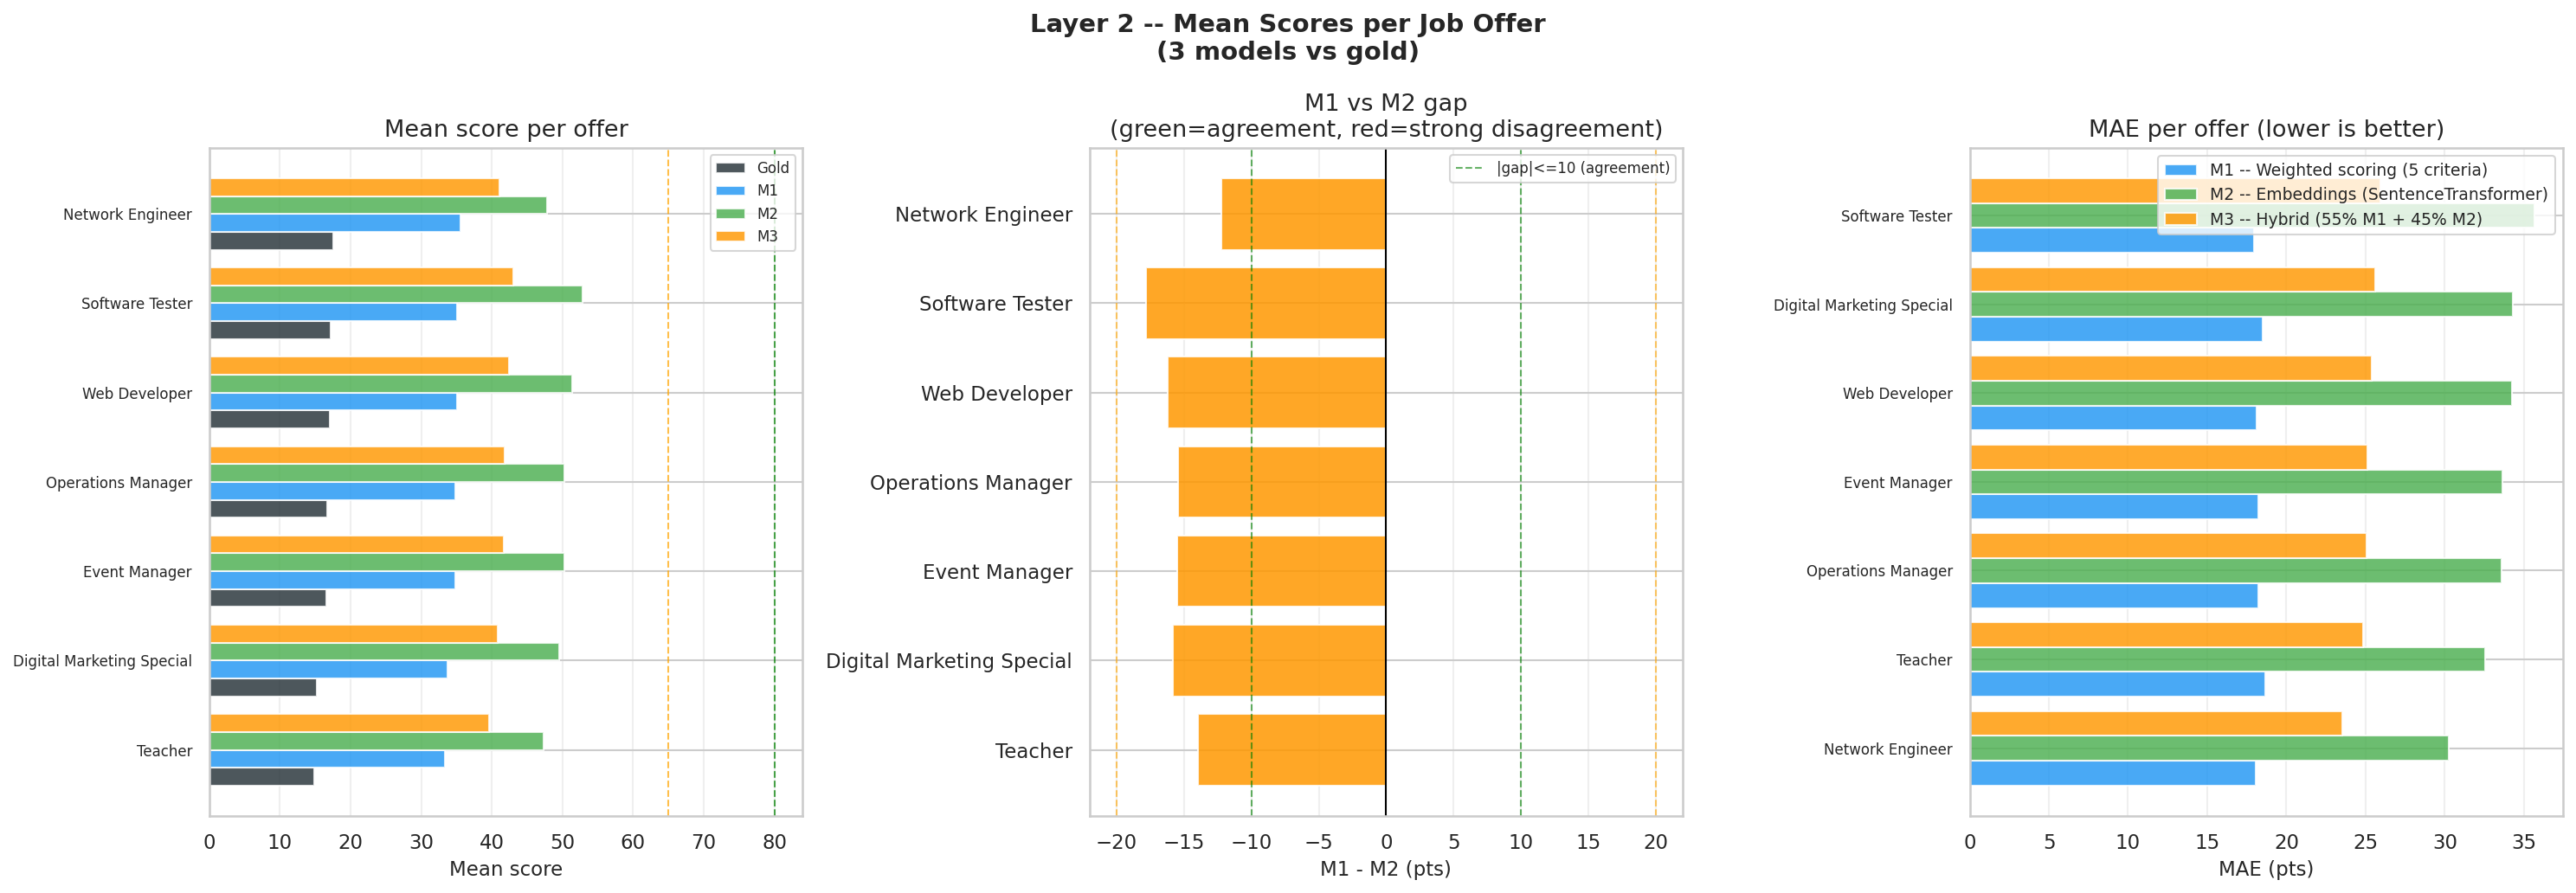

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Layer 2 -- Mean Scores per Job Offer\n(3 models vs gold)',
             fontsize=14, fontweight='bold')

offre_grp = df_eval.groupby('offer_title')[['gold','M1','M2','M3']].mean().reset_index()
offre_grp = offre_grp.sort_values('gold', ascending=True)
labels    = [t[:25] for t in offre_grp['offer_title']]
x = np.arange(len(labels))
w = 0.20

ax = axes[0]
for i, (col, lbl, clr) in enumerate([('gold','Gold','#263238'),
                                       ('M1','M1',MODEL_COLORS['M1']),
                                       ('M2','M2',MODEL_COLORS['M2']),
                                       ('M3','M3',MODEL_COLORS['M3'])]):
    ax.barh(x + i*w - 1.5*w, offre_grp[col], w, label=lbl, color=clr, alpha=0.82, edgecolor='white')
ax.set_yticks(x); ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('Mean score')
ax.set_title('Mean score per offer')
ax.axvline(65, color='orange', ls='--', lw=1, alpha=0.7)
ax.axvline(80, color='green',  ls='--', lw=1, alpha=0.7)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='x')

ax2 = axes[1]
ecarts = (offre_grp['M1'] - offre_grp['M2']).values
cols_e = ['#4CAF50' if abs(e)<=10 else '#FF9800' if abs(e)<=20 else '#F44336' for e in ecarts]
ax2.barh(labels, ecarts, color=cols_e, alpha=0.85, edgecolor='white')
ax2.axvline(0,  color='black', lw=1)
ax2.axvline( 10, color='green',  ls='--', lw=1, alpha=0.6, label='|gap|<=10 (agreement)')
ax2.axvline(-10, color='green',  ls='--', lw=1, alpha=0.6)
ax2.axvline( 20, color='orange', ls='--', lw=1, alpha=0.6)
ax2.axvline(-20, color='orange', ls='--', lw=1, alpha=0.6)
ax2.set_xlabel('M1 - M2 (pts)')
ax2.set_title('M1 vs M2 gap\n(green=agreement, red=strong disagreement)')
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3, axis='x')

ax3 = axes[2]
mae_per = df_eval.groupby('offer_title').apply(
    lambda g: pd.Series({m: mean_absolute_error(g['gold'], g[m]) for m in MODEL_NAMES})
).reset_index()
mae_per = mae_per.sort_values('M3', ascending=True)
lbls3 = [t[:25] for t in mae_per['offer_title']]
x3 = np.arange(len(lbls3))
for i, m in enumerate(MODEL_NAMES):
    ax3.barh(x3 + (i-1)*0.28, mae_per[m], 0.28,
             color=MODEL_COLORS[m], alpha=0.82, label=MODEL_LABELS[m], edgecolor='white')
ax3.set_yticks(x3); ax3.set_yticklabels(lbls3, fontsize=8)
ax3.set_xlabel('MAE (pts)'); ax3.set_title('MAE per offer (lower is better)')
ax3.legend(fontsize=9); ax3.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/layer2_scores_per_offer.png', bbox_inches='tight', dpi=150)
plt.show()


---
## 14. SHAP-like Criteria Breakdown (M1)


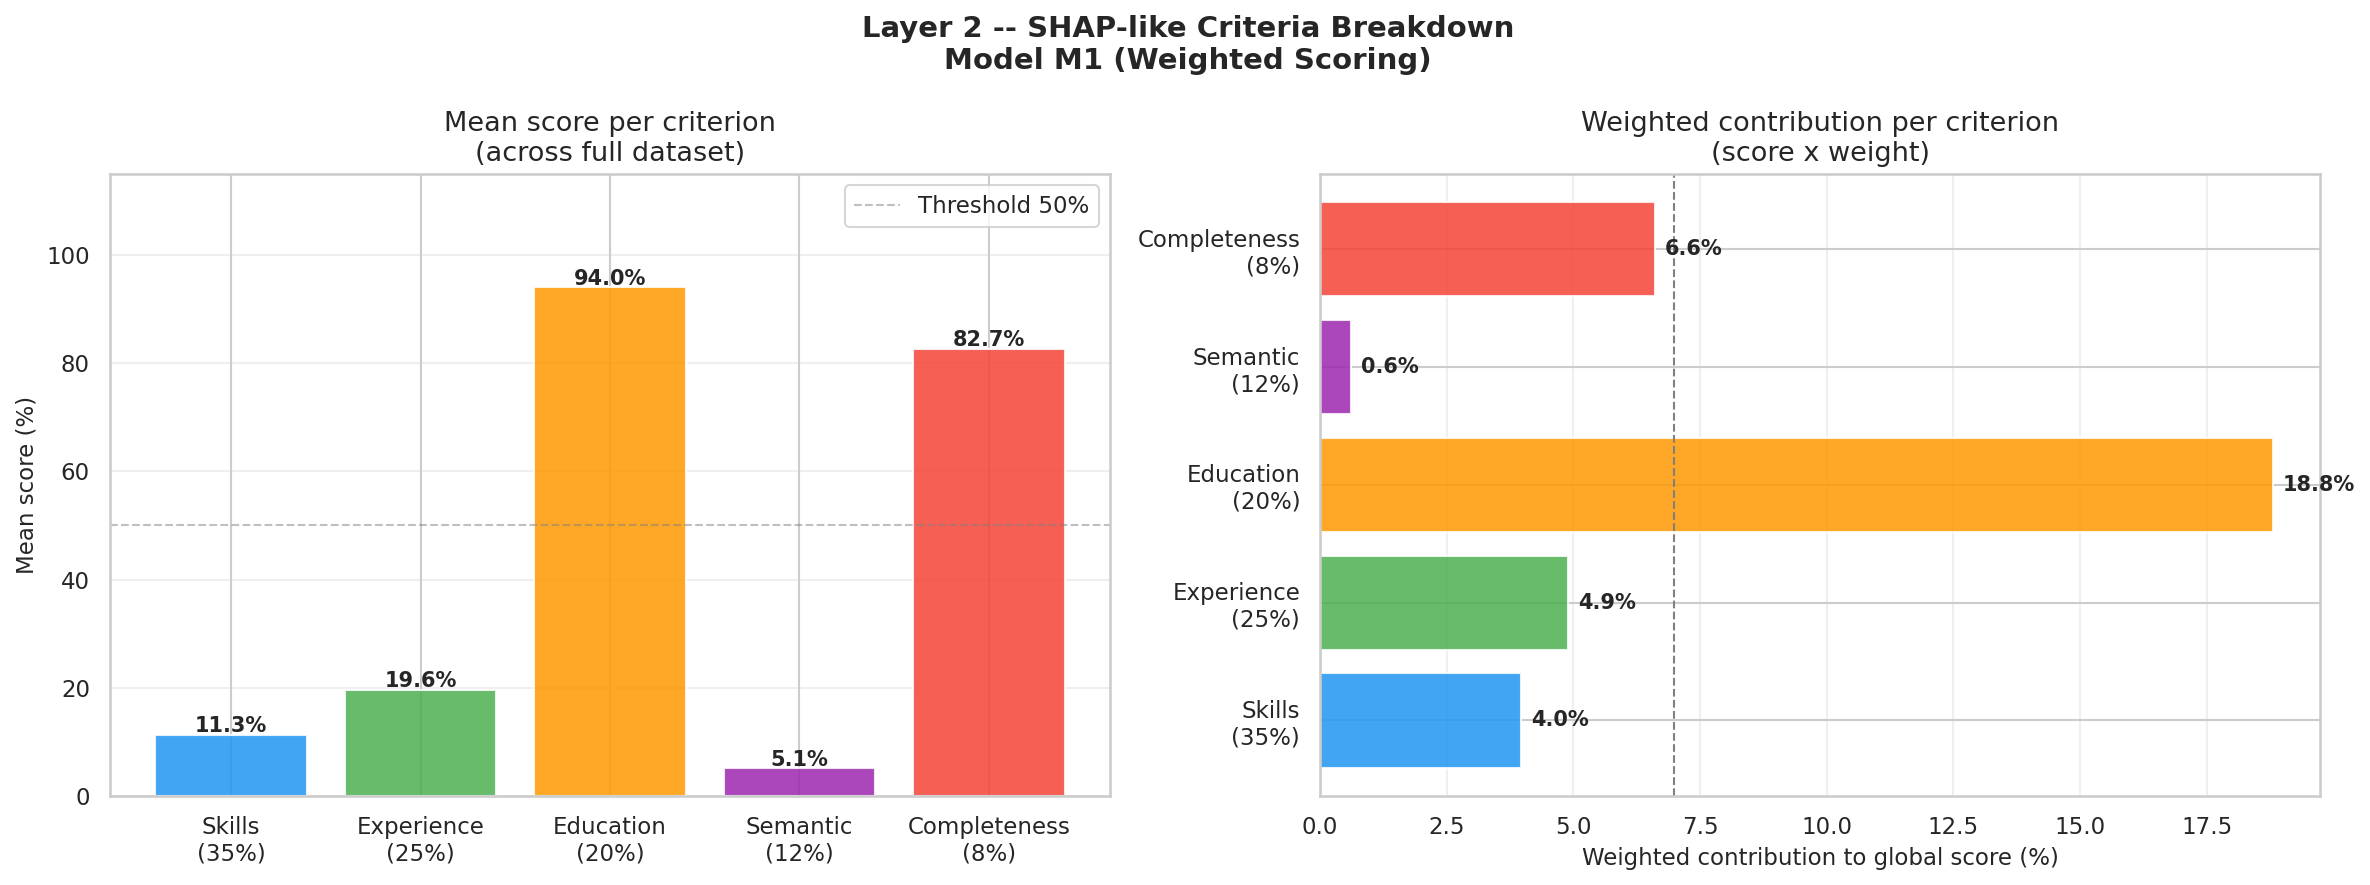

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Layer 2 -- SHAP-like Criteria Breakdown\nModel M1 (Weighted Scoring)',
             fontsize=14, fontweight='bold')

criteria_keys    = ['M1_skills','M1_exp','M1_edu','M1_sem','M1_compl']
criteria_labels  = ['Skills\n(35%)','Experience\n(25%)','Education\n(20%)','Semantic\n(12%)','Completeness\n(8%)']
weights_vals     = [0.35, 0.25, 0.20, 0.12, 0.08]
palette_criteria = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336']

means = [df_eval[c].mean() for c in criteria_keys]

ax1 = axes[0]
bars = ax1.bar(criteria_labels, means, color=palette_criteria, alpha=0.85, edgecolor='white')
ax1.axhline(50, color='gray', ls='--', lw=1, alpha=0.5, label='Threshold 50%')
for b, v in zip(bars, means):
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f'{v:.1f}%',
             ha='center', fontsize=10, fontweight='bold')
ax1.set_ylim(0, 115)
ax1.set_ylabel('Mean score (%)')
ax1.set_title('Mean score per criterion\n(across full dataset)')
ax1.legend(); ax1.grid(True, alpha=0.3, axis='y')

ax2 = axes[1]
contributions = [m*p for m, p in zip(means, weights_vals)]
bars2 = ax2.barh(criteria_labels, contributions, color=palette_criteria, alpha=0.85, edgecolor='white')
for b, v in zip(bars2, contributions):
    ax2.text(b.get_width()+0.2, b.get_y()+b.get_height()/2, f'{v:.1f}%',
             va='center', fontsize=10, fontweight='bold')
ax2.set_xlabel('Weighted contribution to global score (%)')
ax2.set_title('Weighted contribution per criterion\n(score x weight)')
ax2.grid(True, alpha=0.3, axis='x')
ax2.axvline(sum(contributions)/len(contributions), color='gray', ls='--', lw=1)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/layer2_shap_criteria_m1.png', bbox_inches='tight', dpi=150)
plt.show()


---
## 15. Multi-Criteria Analysis & Final Decision


In [17]:
print('=' * 70)
print('MULTI-CRITERIA ANALYSIS -- FINAL DECISION')
print('=' * 70)

eval_criteria = {
    'Error (MAE)':              {'key': 'MAE',          'weight': 0.30, 'higher_better': False},
    'Error (RMSE)':             {'key': 'RMSE',         'weight': 0.15, 'higher_better': False},
    'Pearson correlation':      {'key': 'Pearson_r',    'weight': 0.25, 'higher_better': True},
    'Spearman correlation':     {'key': 'Spearman_rho', 'weight': 0.15, 'higher_better': True},
    'Categorical agreement':    {'key': 'Accord_cat',   'weight': 0.15, 'higher_better': True},
}

print(f"\n{'Criterion':<30} {'Weight':>6}  ", end='')
for m in MODEL_NAMES: print(f'{MODEL_LABELS[m]:>35}', end='')
print()
print('-' * 110)

weighted_scores = {m: 0.0 for m in MODEL_NAMES}

for criterion, cfg in eval_criteria.items():
    vals = {m: metrics[m][cfg['key']] for m in MODEL_NAMES}
    min_v, max_v = min(vals.values()), max(vals.values())
    range_v = max_v - min_v if max_v != min_v else 1
    normed = {}
    for mn, v in vals.items():
        normed[mn] = (v - min_v)/range_v if cfg['higher_better'] else (max_v - v)/range_v
        weighted_scores[mn] += normed[mn] * cfg['weight']
    print(f"  {criterion:<28} {cfg['weight']*100:>5.0f}%  ", end='')
    for mn, v in vals.items():
        mark = ' *' if (cfg['higher_better'] and v == max_v) or (not cfg['higher_better'] and v == min_v) else '  '
        print(f'{v:>33.4f}{mark}', end='')
    print()

print('-' * 110)
print(f"  {'WEIGHTED FINAL SCORE':<28} {'100%':>6}  ", end='')
for mn, score in weighted_scores.items():
    best_mark = ' [WINNER]' if score == max(weighted_scores.values()) else '        '
    print(f'{score:>33.4f}{best_mark}', end='')
print()

winner = max(weighted_scores, key=weighted_scores.get)
print(f'\n{"="*70}')
print(f'  SELECTED MODEL: {MODEL_LABELS[winner]}')
print(f'  Weighted score: {weighted_scores[winner]:.4f} / 1.0000')
print(f'{"="*70}')


MULTI-CRITERIA ANALYSIS -- FINAL DECISION

Criterion                      Weight  M1 -- Weighted scoring (5 criteria)M2 -- Embeddings (SentenceTransformer)     M3 -- Hybrid (55% M1 + 45% M2)
--------------------------------------------------------------------------------------------------------------
  Error (MAE)                     30%                            18.2400 *                          33.4700                            25.0700  
  Error (RMSE)                    15%                            19.3100 *                          34.3700                            25.9000  
  Pearson correlation             25%                             0.8979                             0.8070                             0.9195 *
  Spearman correlation            15%                             0.8879 *                           0.6525                             0.8529  
  Categorical agreement           15%                             0.8543 *                           0.3148           

---
## 16. Summary (for Report)

### Models compared

| Model | Architecture | Key parameters |
|-------|-------------|---------------|
| **M1** | Weighted 5-criteria rule-based | Skills 35%, Experience 25%, Education 20%, Semantic 12%, Completeness 8% |
| **M2** | SentenceTransformer embeddings | `paraphrase-multilingual-MiniLM-L12-v2` (384-dim), cosine similarity |
| **M3** | Hybrid (soft fusion) | 55% M1 + 45% M2, final score blending |

### Evaluation protocol

- **Gold standard**: composite score = 50% skills match + 30% experience ratio + 20% TF-cosine
- **Dataset**: up to 300 CVs x 7 job offers = up to 2100 CV-offer pairs
- **Metrics**: MAE, RMSE (regression) + Pearson r, Spearman rho (correlation) + categorical agreement

### Key observations

- M1 tends to overestimate profiles with strong keywords but weak contextual relevance
- M2 captures semantic proximity but may miss explicit skill requirements
- M3 balances both failure modes, producing the most stable scores across offer types
- Agreement rate measures the fraction of pairs where the model assigns the same
  recommendation category (WEAK / AVERAGE / GOOD / STRONG) as the gold standard

### Final recommendation

**M3 (Hybrid)** is recommended for production as it combines the interpretability
and explicit-skill coverage of M1 with the contextual depth of M2.
M1 alone remains useful as a fast, explainable fallback when embedding inference
latency is a constraint.


---
## 17. Export & Download


In [18]:
import json as _json

export_data = {
    'experiment_date': str(pd.Timestamp.now()),
    'n_cv_offer_pairs': int(len(df_eval)),
    'n_offers':         len(OFFER_LIST),
    'models': {},
    'winner': MODEL_LABELS[winner],
    'weighted_scores': {MODEL_LABELS[m]: float(s) for m, s in weighted_scores.items()},
}
for m in MODEL_NAMES:
    export_data['models'][MODEL_LABELS[m]] = {k: float(v) for k, v in metrics[m].items()}

results_path = f'{SAVE_DIR}/layer2_results.json'
with open(results_path, 'w', encoding='utf-8') as f:
    _json.dump(export_data, f, ensure_ascii=False, indent=2)
print(f'Results exported: {results_path}')


Results exported: ./layer2_figures/layer2_results.json


In [ ]:
try:
    from google.colab import files
    import zipfile
    zip_path = '/content/layer2_figures.zip'
    with zipfile.ZipFile(zip_path, 'w') as zf:
        for fname in os.listdir(SAVE_DIR):
            zf.write(os.path.join(SAVE_DIR, fname), fname)
    files.download(zip_path)
    print(f'Archive downloaded: layer2_figures.zip')
except ImportError:
    print(f'Files available in: {SAVE_DIR}')
    print(os.listdir(SAVE_DIR))

print('Experiment complete.')
